In [1]:
# Use OpenAI GPT-4.1 via LangGraph to extract the core conversation content from each message in df['content']
# and summarize it in a sentence.

from openai import OpenAI
import os
from dotenv import load_dotenv
import json
import os
import sys
import numpy as np
import uuid
import pandas as pd
from py2neo import Graph
import textwrap

# Load environment variables from secret/.env
load_dotenv(dotenv_path="secret/.env")

api_key = os.getenv("OPENAI_API_KEY")
# Set your OpenAI API key (ensure you have it in your environment or replace with your key)
client = OpenAI(api_key=api_key)
from langchain_openai import ChatOpenAI,OpenAIEmbeddings

from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_community.utilities import SQLDatabase
from sqlalchemy import create_engine
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage,RemoveMessage,ToolMessage


from langgraph.prebuilt import create_react_agent
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_core.output_parsers import JsonOutputParser

from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph,END
from langgraph.prebuilt import tools_condition, ToolNode
# from IPython.display import Image, display

import ast
import re
import numpy as np

from langchain.agents.agent_toolkits import create_retriever_tool
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
import textwrap

from langchain.prompts import PromptTemplate
from difflib import get_close_matches
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import trim_messages

In [2]:
llm=ChatOpenAI(model="gpt-4.1",temperature=0)


In [3]:
chatbot_df=pd.read_csv("data/topic_model.csv")
chatbot_df.head()

,content,timestamp,date,timeblock,source_entity_type,target_entity_type,source,target,hour,time,mins_since_start_of_day,packet_id,Message_ID,Processed_Text,Entities,source_entity,target_entity,cluster,topic
0,"hey the intern, it's the lookout! just spotted...",01/10/40 8:09,01/10/40,8:15,Person,Person,the lookout,the intern,8,8:09:00,0,1,1,just spotted a pod of dolphins near the easter...,[],the lookout,the intern,6,Birdwatching
1,"hey the lookout, the intern here! i'd absolute...",01/10/40 8:10,01/10/40,8:15,Person,Person,the intern,the lookout,8,8:10:00,1,1,2,i'd absolutely love to join you for birdwatchi...,['mrs. money'],the intern,the lookout,6,Birdwatching
2,"sam, it's kelly! let's meet at sunrise point a...",01/10/40 8:13,01/10/40,8:15,Person,Person,kelly,sam,8,8:13:00,4,1,3,let's meet at sunrise point at 7 am for birdwa...,['sunrise point'],kelly,sam,6,Birdwatching
3,"mrs. money, it's the intern. just checking in ...",01/10/40 8:16,01/10/40,8:30,Person,Person,the intern,mrs. money,8,8:16:00,7,1,4,just checking in to see what tasks you need he...,['the lookout'],the intern,mrs. money,6,Birdwatching
4,"boss, it's mrs. money. i've reviewed our opera...",01/10/40 8:19,01/10/40,8:30,Person,Person,mrs. money,boss,8,8:19:00,10,1,5,i've reviewed our operational funding for the ...,['the middleman'],mrs. money,boss,8,Project Coordination Schedule


In [4]:
chatbot_df.drop(columns=['content','mins_since_start_of_day'],inplace=True)

In [5]:
chatbot_df.head()

,timestamp,date,timeblock,source_entity_type,target_entity_type,source,target,hour,time,packet_id,Message_ID,Processed_Text,Entities,source_entity,target_entity,cluster,topic
0,01/10/40 8:09,01/10/40,8:15,Person,Person,the lookout,the intern,8,8:09:00,1,1,just spotted a pod of dolphins near the easter...,[],the lookout,the intern,6,Birdwatching
1,01/10/40 8:10,01/10/40,8:15,Person,Person,the intern,the lookout,8,8:10:00,1,2,i'd absolutely love to join you for birdwatchi...,['mrs. money'],the intern,the lookout,6,Birdwatching
2,01/10/40 8:13,01/10/40,8:15,Person,Person,kelly,sam,8,8:13:00,1,3,let's meet at sunrise point at 7 am for birdwa...,['sunrise point'],kelly,sam,6,Birdwatching
3,01/10/40 8:16,01/10/40,8:30,Person,Person,the intern,mrs. money,8,8:16:00,1,4,just checking in to see what tasks you need he...,['the lookout'],the intern,mrs. money,6,Birdwatching
4,01/10/40 8:19,01/10/40,8:30,Person,Person,mrs. money,boss,8,8:19:00,1,5,i've reviewed our operational funding for the ...,['the middleman'],mrs. money,boss,8,Project Coordination Schedule


In [6]:
from langchain_community.utilities import SQLDatabase
from sqlalchemy import create_engine
engine = create_engine("sqlite:///mc3.db")
chatbot_df.to_sql("mc3data", engine, index=False,if_exists='replace')

580

In [7]:
# import sqlite3

# # Save to SQLite
# conn = sqlite3.connect("boat_communications.db")
# chatbot_df.to_sql("communications", conn, if_exists="replace", index=False)

In [8]:
db = SQLDatabase(engine=engine)
print(db.dialect)
print(db.get_usable_table_names())
db.run("SELECT DISTINCT target,topic FROM mc3data;")

sqlite
['mc3data']


"[('the intern', 'Birdwatching'), ('the lookout', 'Birdwatching'), ('sam', 'Birdwatching'), ('mrs. money', 'Birdwatching'), ('boss', 'Project Coordination Schedule'), ('mrs. money', 'Project Coordination Schedule'), ('boss', 'Reef Surveillance'), ('the middleman', 'Reef Surveillance'), ('mako', 'Reef Surveillance'), ('serenity', 'Birdwatching'), ('reef guardian', 'Boundary Violations Monitoring'), ('mako', 'Vessel Operations Coordination'), ('davis', 'Birdwatching'), ('mrs. money', 'Reef Surveillance'), ('serenity', 'Boundary Violations Monitoring'), ('himark harbor', 'Vessel Identification Compliance'), ('serenity', 'Vessel Operations Coordination'), ('remora', 'Boundary Violations Monitoring'), ('paackland harbor', 'Boundary Violations Monitoring'), ('oceanus city council', 'Boundary Violations Monitoring'), ('liam thorne', 'Boundary Violations Monitoring'), ('paackland harbor', 'Vessel Identification Compliance'), ('marlin', 'Vessel Identification Compliance'), ('oceanus city counci

In [9]:
from langchain_core.messages import HumanMessage,SystemMessage
from langgraph.prebuilt import create_react_agent
from langchain_community.agent_toolkits import SQLDatabaseToolkit
toolkit = SQLDatabaseToolkit(db=db, llm=llm)

tools = toolkit.get_tools()

tools

bot_tools=[]
for t in tools:
  bot_tools.append(t)

llm_with_tools=llm.bind_tools(bot_tools)

In [14]:
system_prompt = f"""
You are a smart agent designed to interface with a SQLite database of boat radio communications.
Each communication entry includes a timestamp, timeblock, date, source, target, identified entities, topics, clusters, and other attributes.

Your job is to:
- Convert a user's natural language question into a syntactically correct SQLite query.
- Execute the query using the tools available.
- Interpret the results and answer the user's question clearly.
- Highlight relevant temporal patterns (hours, dates) and related entities when possible.

Guidelines:
1. Only query **relevant columns** based on the question.
2. NEVER use `SELECT *` — choose only what's necessary.
3. Prioritize temporal ordering (`ORDER BY timestamp` or `time`) if the question implies time.
4. For vague names, use approximate match tools (`LIKE` or entity similarity if available).
5. NEVER write `INSERT`, `UPDATE`, or `DELETE` queries.
6. If a query fails, correct and retry after double-checking the syntax.

You have access to the following table(s): {db.get_usable_table_names()}.

After executing the query, summarize the results in context. Discuss any temporal patterns and relevant entities involved.
"""

system_message = SystemMessage(content=system_prompt)

In [24]:
class ExtendedMessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built
    use_sql: bool

In [22]:
def process_conversation(state: ExtendedMessagesState):
    use_sql=True
    # msgs=[llm_with_tools.invoke([system_message + state['messages']])]
    # print(msgs)
    # return {'messages':msgs}

    final_output={"messages":llm_with_tools.invoke([system_message] + state["messages"])}

    return final_output

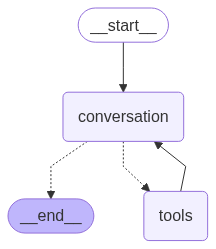

In [25]:
builder = StateGraph(ExtendedMessagesState)

builder.add_node("conversation", process_conversation)

builder.add_node("tools", ToolNode(bot_tools))

builder.add_conditional_edges("conversation",tools_condition)

builder.add_edge("tools", "conversation")

builder.add_edge(START, "conversation")

builder.add_edge("conversation", END)

react_graph = builder.compile()

react_graph

In [38]:
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)
# Specify a thread
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

print("Running on thread..",config['configurable']['thread_id'])

Running on thread.. 5422a178-1fbf-4dab-962f-a1956c837997


In [39]:
question="What is the role of Davis?"

In [43]:
question="Which vessel is Davis is a captain of? can you infer anything out of the data?"

In [44]:
responses=react_graph_memory.invoke({"messages": [question]},config)

In [45]:
responses['messages'][-1].content

'Based on the data, there is no explicit statement that Davis is the captain of a specific vessel. However, there are strong indications that Davis has a leadership or command role—possibly as captain or operations chief—over the vessels "mako" and "remora":\n\n- Davis frequently communicates directly with these vessels, often giving instructions or receiving operational updates.\n- Example: On 02/10/40, Davis gives feedback and requests a discussion about site assessments to "mako," suggesting authority over operational decisions.\n- On 04/10/40, Davis instructs "remora" on how to handle inquiries from harbor authorities, again showing a leadership role.\n\nThe vessels most closely associated with Davis in this context are:\n- mako\n- remora\n\nDavis is not shown giving orders to "marlin," "neptune," or "knowles" in the same direct way, though there is communication.\n\nInference: Davis is likely the captain or operational lead for "mako" and possibly "remora," given the pattern of di

In [49]:
chatbot_response=print(responses['messages'][-1].content)
chatbot_response

Based on the data, there is no explicit statement that Davis is the captain of a specific vessel. However, there are strong indications that Davis has a leadership or command role—possibly as captain or operations chief—over the vessels "mako" and "remora":

- Davis frequently communicates directly with these vessels, often giving instructions or receiving operational updates.
- Example: On 02/10/40, Davis gives feedback and requests a discussion about site assessments to "mako," suggesting authority over operational decisions.
- On 04/10/40, Davis instructs "remora" on how to handle inquiries from harbor authorities, again showing a leadership role.

The vessels most closely associated with Davis in this context are:
- mako
- remora

Davis is not shown giving orders to "marlin," "neptune," or "knowles" in the same direct way, though there is communication.

Inference: Davis is likely the captain or operational lead for "mako" and possibly "remora," given the pattern of direct, authori

In [37]:
print(responses['messages'][-1].content)

Based on the communications, here is the difference between permit #cr-7844 and NR-1045:

Permit #cr-7844:
- Is a special marine research permit, primarily associated with v. miesel shipping and their partners.
- Authorizes equipment transport, research, and operations at Nemo Reef, often involving extended or accelerated schedules.
- Requires detailed documentation and is handled by high-level coordinators like Nadia Conti.
- Is referenced in communications about maintaining operational secrecy, compliance, and coordination among multiple vessels and teams.
- Is used for ongoing, possibly classified or sensitive, research and construction activities at Nemo Reef.

Permit NR-1045 (Priority Event Application NR-1045):
- Is an expedited, high-priority permit, processed with senior official approval (e.g., commissioner Blake of Oceanus City Council).
- Was used to create a special access corridor to Nemo Reef, bypassing standard review protocols under "emergency protocol 7-b."
- Is associ